In [13]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langchain_core.tools import tool
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command

memory = MemorySaver()

In [14]:
from dotenv import load_dotenv
load_dotenv()

True

In [15]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [16]:
import yfinance as yf

@tool
def get_stock_price(symbol: str) -> float:
    """Fetch the latest stock price for a given ticker symbol.

    Args:
        symbol: Stock ticker symbol, e.g. "MSFT", "AAPL", "TSLA".

    Returns:
        The latest traded price as a float.
    """
    ticker = yf.Ticker(symbol)
    price = ticker.fast_info.get("lastPrice")
    if price is None:
        raise ValueError(f"Could not find a price for symbol '{symbol}'")
    return int(price)

@tool
def buy_stocks(symbol: str, quantity: int, total_price: float) -> str:
    '''Buy stocks given in the stck symbol and quantity'''
    decision = interrupt(f"Approve buying {quantity} {symbol} stocks for {total_price: .2f}?")

    if decision == "yes":
        return f"You bought {quantity} shares of {symbol} for a total price of {total_price}"
    else:
        return "Buimg Declined"


tools = [get_stock_price, buy_stocks]
llm = init_chat_model("gemini-3.5-flash-lite", model_provider="google_genai")
llm_with_tools = llm.bind_tools(tools)

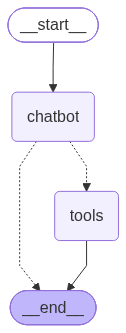

In [18]:
def chatbot(state: State):
    return {"messages" : [llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)

builder.add_node("chatbot", chatbot)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "chatbot")
builder.add_conditional_edges("chatbot", tools_condition)
# builder.add_edge("tools", chatbot)
builder.add_edge("chatbot", END)

graph = builder.compile(checkpointer=memory)
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))


In [ ]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langchain_core.tools import tool
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

In [ ]:
from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [ ]:
import yfinance as yf

@tool
def get_stock_price(symbol: str) -> float:
    """Fetch the latest stock price for a given ticker symbol.

    Args:
        symbol: Stock ticker symbol, e.g. "MSFT", "AAPL", "TSLA".

    Returns:
        The latest traded price as a float.
    """
    ticker = yf.Ticker(symbol)
    price = ticker.fast_info.get("lastPrice")
    if price is None:
        raise ValueError(f"Could not find a price for symbol '{symbol}'")
    return int(price)

tools = [get_stock_price]
llm = init_chat_model("gemini-3.6-flash", model_provider="google_genai")
llm_with_tools = llm.bind_tools(tools)

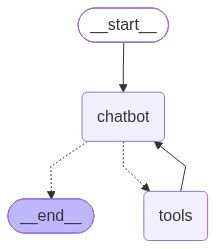

In [ ]:
def chatbot(state: State):
    return {"messages" : [llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)

builder.add_node(chatbot)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "chatbot")
builder.add_conditional_edges("chatbot", tools_condition)
builder.add_edge("tools", "chatbot")
builder.add_edge("chatbot", END)

graph = builder.compile()
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))


In [ ]:
state = graph.invoke({"messages" : [{"role": "user", "content":  "I want to buy 10 msft stock and 10 google stock, what will be the total cost?"}]})
print(state["messages"][-1].content)

KeyboardInterrupt: 

In [ ]:
state = graph.invoke({"messages" : [{"role": "user", "content":  "who was Mahatma Gandhi?"}]})
print(state["messages"][-1].content)

In [23]:
config = {'configurable' : {'thread_id' : "buy_thread"}}
state = graph.invoke({"messages" : [{"role": "user", "content":  "what is the current price of 10 msft stocks?"}]}, config=config)
print(state["messages"][-1].content)

state = graph.invoke({"messages" : [{"role": "user", "content":  "Buy same stocks at current price"}]}, config=config)
print(state.get("__interupt__"))

decision = input("Approve (Yes/No): ")
graph.invoke(Command(resume=decision), config=config)

495
None


{'messages': [HumanMessage(content='what is the current price of 10 msft stocks?', additional_kwargs={}, response_metadata={}, id='fb6cfebc-a09e-4cc4-807a-48c7afd76d35'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'get_stock_price', 'arguments': '{"symbol": "MSFT"}'}, '__gemini_function_call_thought_signatures__': {'call_973505': 'El4KXAERTTIP2BwNryZ1I8T2euAsdRMx9+LX6krJIIwV4khPUOaMdfV9ardSvgiOamPfnoEt846cfaw+HvKEaHmoEUsg4LiuxP36yM2kFqgrfsPVpk/QNKSCxXJwWGD/'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a00e9f-92d2-7a21-8105-68fe2affb45c-0', tool_calls=[{'name': 'get_stock_price', 'args': {'symbol': 'MSFT'}, 'id': 'call_973505', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 178, 'output_tokens': 19, 'total_tokens': 197, 'input_token_details': {'cache_read': 0}}),
  ToolMessage(content='495', name='get_stock_price', id='